# Building Models with Distance Metrics and Nearest Neighbors

Notebook ini membahas model machine learning berbasis ukuran jarak, terutama **K-Nearest Neighbors (KNN)**. Chapter ini menjelaskan bagaimana konsep kemiripan antar data dapat digunakan untuk klasifikasi, bagaimana beberapa distance metric bekerja, bagaimana menerapkan KNN dengan scikit-learn, serta bagaimana melakukan hyperparameter tuning dan evaluasi performa model.

Topik utama:
- Konsep distance metrics
- Euclidean, Manhattan, dan Minkowski distance
- K-Nearest Neighbors untuk klasifikasi
- Pengaruh nilai `k`
- Pengaruh scaling terhadap KNN
- Perbandingan distance metrics
- Hyperparameter tuning dengan GridSearchCV dan RandomizedSearchCV
- Evaluasi KNN dengan cross-validation, learning curve, confusion matrix, dan classification report

## Tujuan Pembelajaran

Setelah mempelajari notebook ini, pembaca diharapkan mampu:

- Memahami konsep jarak dalam machine learning.
- Menjelaskan cara kerja K-Nearest Neighbors.
- Menghitung Euclidean distance, Manhattan distance, dan Minkowski distance.
- Mengimplementasikan KNN classifier menggunakan scikit-learn.
- Menjelaskan pengaruh nilai `k` terhadap performa model.
- Memahami mengapa scaling penting untuk algoritma berbasis jarak.
- Membandingkan beberapa distance metrics.
- Melakukan hyperparameter tuning pada KNN.
- Mengevaluasi performa model menggunakan metrik klasifikasi.

## Persiapan Library

Library yang digunakan pada notebook ini berasal dari `numpy`, `pandas`, `matplotlib`, dan `scikit-learn`. Dataset utama yang digunakan adalah Iris dataset dan dataset sintetis untuk melihat pengaruh distance metrics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_circles, make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, learning_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

np.random.seed(2024)
pd.set_option("display.max_columns", 100)

## Ringkasan Chapter

Distance metrics adalah ukuran untuk menghitung seberapa dekat atau seberapa berbeda dua data dalam ruang fitur. Konsep ini menjadi dasar bagi beberapa algoritma machine learning, salah satunya K-Nearest Neighbors.

KNN bekerja dengan prinsip sederhana: data baru akan diberi label berdasarkan data training terdekatnya. Jika mayoritas tetangga terdekat berasal dari kelas tertentu, maka data baru akan diprediksi sebagai kelas tersebut.

Walaupun sederhana, KNN sangat dipengaruhi oleh beberapa hal:

| Faktor | Dampak |
|---|---|
| Nilai k | Menentukan jumlah tetangga yang digunakan untuk voting |
| Distance metric | Menentukan cara menghitung kedekatan antar data |
| Scaling fitur | Fitur berskala besar dapat mendominasi jarak |
| Dimensi data | Data berdimensi tinggi dapat membuat jarak kurang bermakna |
| Distribusi kelas | Data imbalanced dapat memengaruhi voting |

## Introduction to Distance Metrics

Distance metric digunakan untuk mengukur kedekatan antara dua titik data. Dalam machine learning, jarak sering menjadi dasar untuk membandingkan data, membentuk cluster, atau menentukan kelas dari data baru.

Contoh sederhana: jika dua data memiliki nilai fitur yang mirip, maka jaraknya kecil. Jika nilai fiturnya sangat berbeda, maka jaraknya besar.

Pada KNN, distance metric berperan langsung dalam menentukan tetangga terdekat. Oleh karena itu, pemilihan distance metric dapat memengaruhi hasil klasifikasi.

## Rumus Euclidean Distance

*Euclidean distance* adalah jarak garis lurus antara dua titik. Ini adalah *distance metric* yang paling umum digunakan.

Untuk dua titik $x$ dan $y$ dengan $n$ fitur:

$$d(x,y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$$

Contoh untuk dua dimensi:

$$d(x,y)=\sqrt{(x_1-y_1)^2+(x_2-y_2)^2}$$

*Euclidean distance* cocok untuk data numerik kontinu yang sudah berada pada skala yang sebanding.

## Rumus Manhattan Distance

*Manhattan distance* menghitung jarak sebagai jumlah selisih absolut antar koordinat. *Distance* ini sering disebut juga **city block distance** karena mirip dengan perjalanan pada jalan berbentuk grid.

$$d(x,y) = \sum_{i=1}^{n}|x_i - y_i|$$

*Manhattan distance* dapat lebih sesuai ketika pergerakan atau perbedaan antar fitur lebih masuk akal dihitung secara vertikal-horizontal, bukan garis lurus.

## Rumus Minkowski Distance

*Minkowski distance* adalah generalisasi dari *Euclidean* dan *Manhattan distance*.

$$d(x,y)=\left(\sum_{i=1}^{n}|x_i-y_i|^p\right)^{1/p}$$

Keterangan:

- Jika $p=1$, maka menjadi *Manhattan distance*.
- Jika $p=2$, maka menjadi *Euclidean distance*.

Dengan mengubah nilai $p$, kita dapat mengatur cara jarak dihitung.

## Contoh Perhitungan Distance Metrics

Contoh berikut menghitung jarak antara dua titik sederhana menggunakan Euclidean, Manhattan, dan Minkowski distance.

In [2]:
from scipy.spatial.distance import euclidean, cityblock, minkowski

x = np.array([2, 3])
y = np.array([6, 8])

euclidean_distance = euclidean(x, y)
manhattan_distance = cityblock(x, y)
minkowski_distance_p3 = minkowski(x, y, p=3)

pd.DataFrame({
    "Metric": ["Euclidean", "Manhattan", "Minkowski p=3"],
    "Distance": [euclidean_distance, manhattan_distance, minkowski_distance_p3]
})

,Metric,Distance
0,Euclidean,6.403124
1,Manhattan,9.000000
2,Minkowski p=3,5.738794


## Analisis Distance Metrics

Untuk titik yang sama, nilai jarak bisa berbeda tergantung metric yang digunakan. Hal ini menunjukkan bahwa distance metric bukan sekadar detail teknis, tetapi bagian penting dari desain model.

Jika metric yang dipilih tidak sesuai dengan struktur data, maka tetangga yang dianggap “terdekat” oleh model bisa saja bukan data yang paling relevan secara konsep.

## Understanding K-Nearest Neighbors

KNN adalah algoritma supervised learning yang dapat digunakan untuk klasifikasi dan regresi. Pada klasifikasi, KNN menentukan label data baru berdasarkan mayoritas label dari \(k\) tetangga terdekat.

Cara kerja KNN:

1. Tentukan nilai \(k\).
2. Hitung jarak data baru terhadap seluruh data training.
3. Ambil \(k\) data training dengan jarak paling dekat.
4. Lakukan voting mayoritas kelas.
5. Kelas dengan suara terbanyak menjadi prediksi.

KNN disebut lazy learning karena model tidak benar-benar membangun fungsi eksplisit saat training. Proses utama justru terjadi ketika prediksi dilakukan.

## Rumus Voting KNN

Untuk klasifikasi, prediksi kelas dapat ditulis sebagai:

$$\hat{y} = \arg\max_c \sum_{i \in N_k(x)} I(y_i = c)$$

Keterangan:

- $\hat{y}$ = kelas prediksi
- $c$ = kandidat kelas
- $N_k(x)$ = himpunan $k$ tetangga terdekat dari data $x$
- $I(y_i=c)$ = fungsi indikator, bernilai 1 jika label tetangga sama dengan kelas $c$

Jika menggunakan *weighted voting*, tetangga yang lebih dekat dapat diberi bobot lebih besar.

## Load Dataset Iris

Dataset Iris digunakan untuk contoh dasar KNN. Dataset ini memiliki 4 fitur numerik dan 3 kelas bunga iris.

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

df_iris = pd.DataFrame(X, columns=iris.feature_names)
df_iris["target"] = y
df_iris["species"] = df_iris["target"].map({i: name for i, name in enumerate(iris.target_names)})

print("Shape data:", X.shape)
print("Target names:", iris.target_names)
df_iris.head()

Shape data: (150, 4)
Target names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Train-Test Split

Data dibagi menjadi training set dan test set. Training set digunakan untuk membangun model, sedangkan test set digunakan untuk mengevaluasi kemampuan model terhadap data yang belum pernah dilihat.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2024,
    stratify=y
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 120
Jumlah data testing: 30


## Implementasi KNN Dasar

Contoh berikut menggunakan `KNeighborsClassifier` dengan `n_neighbors=3`.

In [5]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


## Analisis KNN Dasar

KNN dapat menghasilkan performa yang cukup baik pada Iris dataset karena dataset ini relatif kecil, bersih, dan kelasnya cukup terpisah. Namun, pada dataset yang lebih kompleks, performa KNN sangat bergantung pada nilai \(k\), distance metric, dan preprocessing seperti scaling.

## Pengaruh Nilai k

Nilai \(k\) menentukan jumlah tetangga yang digunakan dalam voting.

- \(k\) kecil: model lebih sensitif terhadap noise dan outlier.
- \(k\) besar: model lebih stabil, tetapi bisa terlalu halus dan mengabaikan pola lokal.

Secara umum, nilai \(k\) perlu dicari menggunakan validasi atau cross-validation.

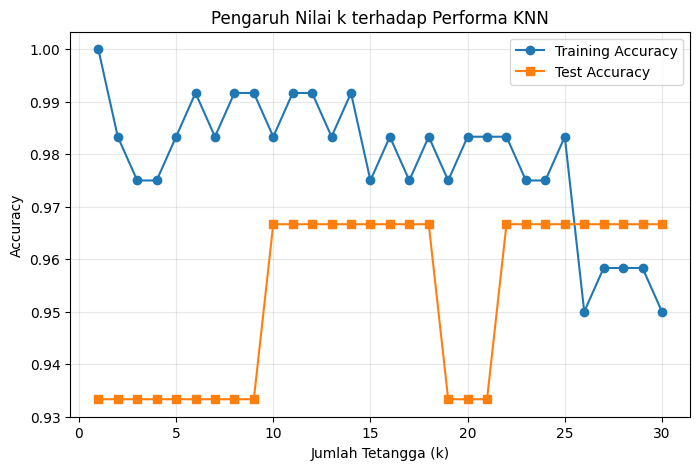

,k,train_accuracy,test_accuracy
0,1,1.000000,0.933333
1,2,0.983333,0.933333
2,3,0.975000,0.933333
3,4,0.975000,0.933333
4,5,0.983333,0.933333
5,6,0.991667,0.933333
6,7,0.983333,0.933333
7,8,0.991667,0.933333
8,9,0.991667,0.933333
9,10,0.983333,0.966667


In [6]:
k_values = range(1, 31)
train_scores = []
test_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(k_values, train_scores, marker="o", label="Training Accuracy")
plt.plot(k_values, test_scores, marker="s", label="Test Accuracy")
plt.xlabel("Jumlah Tetangga (k)")
plt.ylabel("Accuracy")
plt.title("Pengaruh Nilai k terhadap Performa KNN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({
    "k": list(k_values),
    "train_accuracy": train_scores,
    "test_accuracy": test_scores
}).head(10)

## Analisis Pengaruh k

Saat \(k=1\), model cenderung sangat mengikuti data training. Ini dapat menghasilkan training accuracy tinggi, tetapi lebih rentan overfitting. Ketika \(k\) meningkat, batas keputusan menjadi lebih halus. Namun jika \(k\) terlalu besar, model dapat menjadi terlalu sederhana dan kehilangan pola lokal.

## Mengapa Scaling Penting pada KNN?

KNN menghitung jarak antar titik. Jika satu fitur memiliki skala jauh lebih besar dari fitur lain, maka fitur tersebut akan mendominasi perhitungan jarak.

Contoh:
- Fitur umur: 0 sampai 100
- Fitur pendapatan: 0 sampai 100.000.000

Tanpa scaling, pendapatan akan jauh lebih dominan dibandingkan umur. Oleh karena itu, scaling sangat penting untuk algoritma berbasis jarak seperti KNN.

## KNN dengan Pipeline dan StandardScaler

Pipeline digunakan agar scaling dilakukan dengan benar. Scaler hanya dipelajari dari data training, kemudian digunakan untuk mentransformasi data testing.

In [7]:
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3))
])

pipe_knn.fit(X_train, y_train)

y_pred_scaled = pipe_knn.predict(X_test)

print("Accuracy KNN tanpa scaling:", accuracy_score(y_test, y_pred))
print("Accuracy KNN dengan scaling:", accuracy_score(y_test, y_pred_scaled))

Accuracy KNN tanpa scaling: 0.9333333333333333
Accuracy KNN dengan scaling: 0.9333333333333333


## Distance Metrics Overview

Selain *Euclidean distance*, KNN juga dapat menggunakan *distance metric* lain seperti *Manhattan* dan *Minkowski*. Pemilihan *metric* dapat bergantung pada struktur data.

| Metric | Rumus Umum | Cocok untuk |
| :--- | :--- | :--- |
| Euclidean | $\sqrt{\sum(x_i-y_i)^2}$ | Data numerik kontinu, *cluster* alami |
| Manhattan | $\sum \|x_i-y_i\|$ | Pola grid, data dengan *outlier* |
| Minkowski | $(\sum \|x_i-y_i\|^p)^{1/p}$ | Generalisasi Euclidean dan Manhattan |
| Cosine Similarity | $\frac{x \cdot y}{\|x\| \|y\|}$ | Teks, *embedding*, rekomendasi |
| Hamming | Proporsi elemen berbeda | Data biner/kategorikal |

## Dataset Sintetis untuk Membandingkan Metrics

Contoh berikut menggunakan dua dataset sintetis:
1. Dataset lingkaran dengan noise.
2. Dataset checkerboard/grid.

Tujuannya adalah menunjukkan bahwa distance metric dapat memberikan performa berbeda pada struktur data yang berbeda.

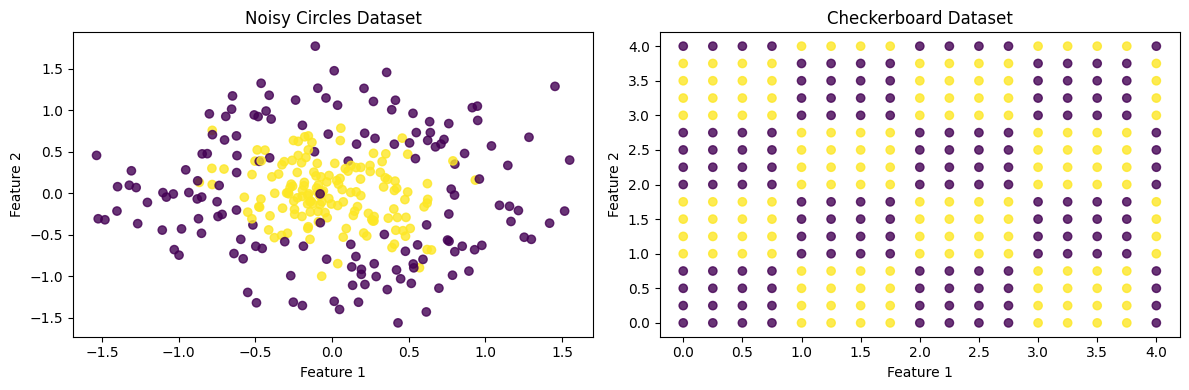

In [8]:
n_samples = 300

X_circles, y_circles = make_circles(
    n_samples=n_samples,
    noise=0.3,
    factor=0.3,
    random_state=2024
)

x_grid = np.linspace(0, 4, int(np.sqrt(n_samples)))
y_grid = np.linspace(0, 4, int(np.sqrt(n_samples)))
xx, yy = np.meshgrid(x_grid, y_grid)

X_checker = np.column_stack((xx.ravel(), yy.ravel()))
y_checker = np.mod(np.floor(xx.ravel()) + np.floor(yy.ravel()), 2).astype(int)

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_circles, y_circles, test_size=0.2, random_state=2024, stratify=y_circles
)

X_ch_train, X_ch_test, y_ch_train, y_ch_test = train_test_split(
    X_checker, y_checker, test_size=0.2, random_state=2024, stratify=y_checker
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap="viridis", alpha=0.8)
plt.title("Noisy Circles Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.subplot(1, 2, 2)
plt.scatter(X_checker[:, 0], X_checker[:, 1], c=y_checker, cmap="viridis", alpha=0.8)
plt.title("Checkerboard Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

## Membandingkan Euclidean, Manhattan, dan Minkowski

Kita akan melatih KNN menggunakan beberapa metric dan membandingkan accuracy-nya.

In [9]:
metrics = ["euclidean", "manhattan", "minkowski"]

results = []

for metric in metrics:
    model_circles = KNeighborsClassifier(n_neighbors=3, metric=metric)
    model_circles.fit(X_c_train, y_c_train)
    pred_circles = model_circles.predict(X_c_test)

    model_checker = KNeighborsClassifier(n_neighbors=3, metric=metric)
    model_checker.fit(X_ch_train, y_ch_train)
    pred_checker = model_checker.predict(X_ch_test)

    results.append({
        "metric": metric,
        "circles_accuracy": accuracy_score(y_c_test, pred_circles),
        "checkerboard_accuracy": accuracy_score(y_ch_test, pred_checker)
    })

results_df = pd.DataFrame(results)
results_df

,metric,circles_accuracy,checkerboard_accuracy
0,euclidean,0.866667,0.810345
1,manhattan,0.866667,0.827586
2,minkowski,0.866667,0.810345


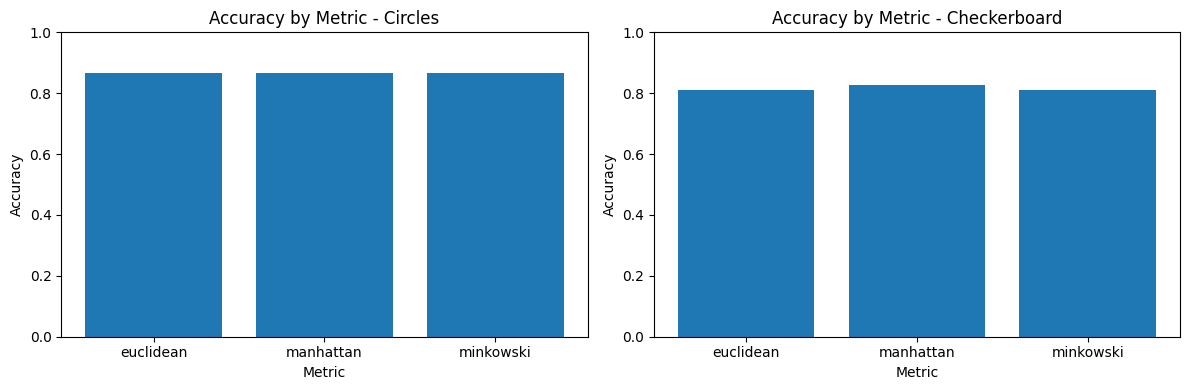

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(results_df["metric"], results_df["circles_accuracy"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Accuracy by Metric - Circles")
axes[0].set_xlabel("Metric")
axes[0].set_ylabel("Accuracy")

axes[1].bar(results_df["metric"], results_df["checkerboard_accuracy"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Accuracy by Metric - Checkerboard")
axes[1].set_xlabel("Metric")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

## Analisis Distance Metric

Hasil eksperimen menunjukkan bahwa metric yang berbeda dapat menghasilkan performa yang berbeda. Tidak ada satu distance metric yang selalu paling baik untuk semua dataset.

Hal yang perlu diperhatikan:
- Euclidean sering menjadi default untuk data numerik kontinu.
- Manhattan bisa lebih cocok pada pola grid atau data yang memiliki perbedaan absolut.
- Minkowski memberikan fleksibilitas melalui parameter \(p\).
- Untuk data teks atau embedding, cosine similarity sering lebih masuk akal.

## Hyperparameter Tuning pada KNN

Hyperparameter adalah nilai yang ditentukan sebelum proses training. Pada KNN, beberapa hyperparameter penting adalah:

| Hyperparameter | Fungsi |
|---|---|
| `n_neighbors` | Jumlah tetangga yang digunakan |
| `weights` | Cara memberi bobot tetangga, misalnya uniform atau distance |
| `metric` | Distance metric yang digunakan |
| `p` | Parameter Minkowski distance |

Tuning dilakukan untuk mencari kombinasi hyperparameter yang memberikan performa terbaik.

## Grid Search untuk KNN

Grid Search mencoba seluruh kombinasi hyperparameter yang ditentukan. Cross-validation digunakan agar pemilihan parameter lebih stabil dan tidak hanya bergantung pada satu split data.

In [11]:
param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan", "minkowski"]
}

grid_search = GridSearchCV(
    pipe_knn,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)
print("Test score:", grid_search.score(X_test, y_test))

Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'knn__weights': 'distance'}
Best cross-validation score: 0.975
Test score: 0.9333333333333333


## Hasil Grid Search

`best_params_` menunjukkan kombinasi hyperparameter terbaik berdasarkan cross-validation. `best_score_` menunjukkan rata-rata score validasi terbaik. Namun, evaluasi akhir tetap perlu dilakukan pada test set.

Grid search cocok untuk search space kecil sampai sedang. Jika kombinasi parameter sangat banyak, prosesnya bisa menjadi lambat.

In [12]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results[[
    "param_knn__n_neighbors",
    "param_knn__weights",
    "param_knn__metric",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score").head(10)

,param_knn__n_neighbors,param_knn__weights,param_knn__metric,mean_test_score,std_test_score,rank_test_score
3,5,distance,euclidean,0.975000,0.033333,1
15,7,distance,manhattan,0.975000,0.020412,1
23,5,distance,minkowski,0.975000,0.033333,1
17,9,distance,manhattan,0.975000,0.020412,1
5,7,distance,euclidean,0.966667,0.031180,5
26,9,uniform,minkowski,0.966667,0.031180,5
6,9,uniform,euclidean,0.966667,0.031180,5
7,9,distance,euclidean,0.966667,0.031180,5
25,7,distance,minkowski,0.966667,0.031180,5
27,9,distance,minkowski,0.966667,0.031180,5


## Randomized Search

RandomizedSearchCV tidak mencoba semua kombinasi, tetapi mengambil sampel acak dari ruang parameter. Teknik ini berguna ketika jumlah kombinasi sangat besar.

In [13]:
from scipy.stats import randint

random_param_dist = {
    "knn__n_neighbors": randint(1, 30),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan", "minkowski"]
}

random_search = RandomizedSearchCV(
    pipe_knn,
    random_param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=2024
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best cross-validation score:", random_search.best_score_)
print("Test score:", random_search.score(X_test, y_test))

Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 9, 'knn__weights': 'distance'}
Best cross-validation score: 0.9666666666666668
Test score: 0.9333333333333333


## Evaluating KNN Performance

Evaluasi model tidak cukup hanya menggunakan *accuracy*. Kita juga perlu melihat metrik lain seperti *confusion matrix*, *precision*, *recall*, dan *F1-score*.

Metrik utama:

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP}$$

$$Recall = \frac{TP}{TP + FN}$$

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

Keterangan:
- $TP$ = *True Positive*
- $TN$ = *True Negative*
- $FP$ = *False Positive*
- $FN$ = *False Negative*

## Cross-Validation Score Model Terbaik

Cross-validation memberikan gambaran stabilitas performa model pada beberapa split data.

In [14]:
best_model = grid_search.best_estimator_

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5
)

print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation scores: [0.95833333 1.         1.         1.         0.91666667]
Mean CV score: 0.975
Standard deviation: 0.03333333333333334


## Learning Curve

Learning curve menunjukkan hubungan antara jumlah data training dan performa model. Grafik ini dapat membantu melihat apakah model mengalami underfitting, overfitting, atau masih membutuhkan lebih banyak data.

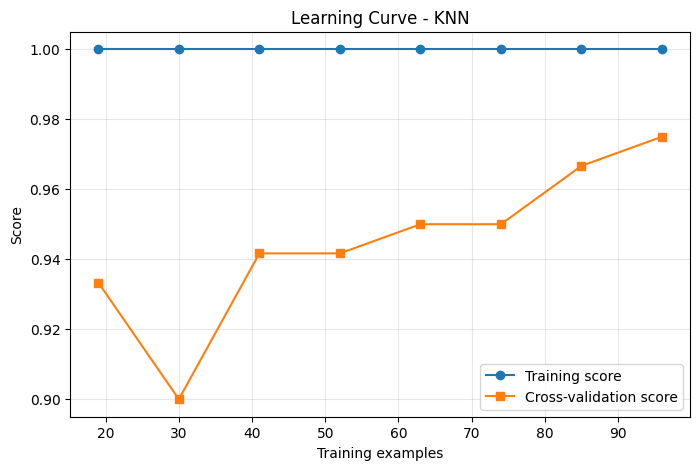

In [15]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    train_sizes=np.linspace(0.2, 1.0, 8),
    cv=5
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training score")
plt.plot(train_sizes, test_mean, marker="s", label="Cross-validation score")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.title("Learning Curve - KNN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Confusion Matrix

Confusion matrix menunjukkan jumlah prediksi benar dan salah untuk setiap kelas. Nilai diagonal menunjukkan prediksi benar, sedangkan nilai di luar diagonal menunjukkan kesalahan klasifikasi.

In [16]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

cm_df = pd.DataFrame(
    cm,
    index=[f"True {name}" for name in iris.target_names],
    columns=[f"Predicted {name}" for name in iris.target_names]
)

cm_df

,Predicted setosa,Predicted versicolor,Predicted virginica
True setosa,10,0,0
True versicolor,0,9,1
True virginica,0,1,9


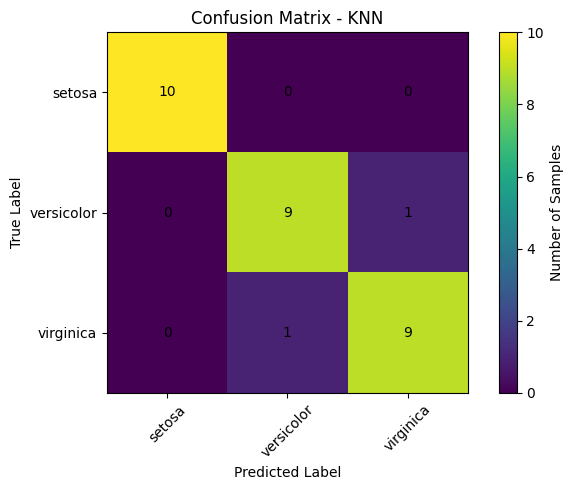

In [17]:
plt.figure(figsize=(7, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(iris.target_names)), iris.target_names, rotation=45)
plt.yticks(np.arange(len(iris.target_names)), iris.target_names)
plt.colorbar(label="Number of Samples")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## Classification Report

Classification report menggabungkan beberapa metrik seperti precision, recall, F1-score, dan support untuk setiap kelas.

In [18]:
report = classification_report(
    y_test,
    y_pred_best,
    target_names=iris.target_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
setosa,1.000000,1.000000,1.000000,10.000000
versicolor,0.900000,0.900000,0.900000,10.000000
virginica,0.900000,0.900000,0.900000,10.000000
accuracy,0.933333,0.933333,0.933333,0.933333
macro avg,0.933333,0.933333,0.933333,30.000000
weighted avg,0.933333,0.933333,0.933333,30.000000


## Analisis Evaluasi KNN

Jika nilai precision, recall, dan F1-score tinggi pada semua kelas, maka model mampu memprediksi setiap kelas dengan baik. Jika salah satu kelas memiliki recall rendah, artinya banyak data dari kelas tersebut gagal dikenali.

Pada dataset Iris, kelas `setosa` biasanya mudah dipisahkan, sedangkan `versicolor` dan `virginica` lebih sering tertukar karena karakteristik fiturnya lebih mirip.

## Handling Imbalanced Datasets

Accuracy dapat menyesatkan ketika dataset tidak seimbang. Misalnya, jika 95% data berasal dari kelas A, model yang selalu menebak kelas A bisa mendapatkan accuracy 95%, tetapi sebenarnya buruk untuk mendeteksi kelas minoritas.

Pada dataset imbalanced, metrik yang lebih relevan dapat berupa:
- Precision
- Recall
- F1-score
- ROC-AUC
- Precision-recall curve

Selain itu, teknik resampling seperti oversampling dan undersampling dapat dipertimbangkan.

## Mini Studi Kasus: Data Imbalanced

Contoh berikut membuat dataset imbalanced dan menunjukkan mengapa accuracy saja tidak cukup.

In [19]:
X_imb, y_imb = make_classification(
    n_samples=1000,
    n_features=8,
    n_informative=3,
    n_redundant=2,
    weights=[0.92, 0.08],
    random_state=2024
)

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb,
    y_imb,
    test_size=0.25,
    random_state=2024,
    stratify=y_imb
)

imb_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

imb_pipe.fit(X_train_imb, y_train_imb)
y_pred_imb = imb_pipe.predict(X_test_imb)

print("Accuracy:", accuracy_score(y_test_imb, y_pred_imb))
print("Precision:", precision_score(y_test_imb, y_pred_imb))
print("Recall:", recall_score(y_test_imb, y_pred_imb))
print("F1-score:", f1_score(y_test_imb, y_pred_imb))
print("\\nClassification Report:")
print(classification_report(y_test_imb, y_pred_imb))

Accuracy: 0.968
Precision: 1.0
Recall: 0.6190476190476191
F1-score: 0.7647058823529411
\nClassification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       229
           1       1.00      0.62      0.76        21

    accuracy                           0.97       250
   macro avg       0.98      0.81      0.87       250
weighted avg       0.97      0.97      0.96       250



## Analisis Data Imbalanced

Pada dataset imbalanced, accuracy bisa terlihat cukup tinggi meskipun model tidak terlalu baik dalam mengenali kelas minoritas. Oleh karena itu, recall dan F1-score menjadi penting jika tujuan model adalah menemukan sebanyak mungkin data positif/minoritas.

Pemilihan metrik harus selalu disesuaikan dengan konteks masalah.

## Ringkasan Konsep Penting

| Konsep | Penjelasan |
|---|---|
| Distance metric | Ukuran kedekatan antar data |
| Euclidean distance | Jarak garis lurus |
| Manhattan distance | Jumlah selisih absolut |
| Minkowski distance | Generalisasi Manhattan dan Euclidean |
| KNN | Prediksi berdasarkan tetangga terdekat |
| Nilai k | Jumlah tetangga dalam voting |
| Scaling | Penting agar jarak tidak didominasi fitur tertentu |
| GridSearchCV | Mencari hyperparameter terbaik secara exhaustive |
| RandomizedSearchCV | Mencari hyperparameter dengan sampling acak |
| Confusion matrix | Menampilkan prediksi benar dan salah per kelas |
| Classification report | Menampilkan precision, recall, F1-score, dan support |

## Kesimpulan Chapter

Chapter ini menjelaskan bahwa konsep jarak merupakan dasar penting dalam beberapa algoritma machine learning, terutama K-Nearest Neighbors. KNN mengklasifikasikan data baru berdasarkan label mayoritas dari tetangga terdekatnya.

Poin penting dari chapter ini:

- Distance metric menentukan bagaimana kemiripan antar data dihitung.
- Euclidean, Manhattan, dan Minkowski distance memiliki karakteristik berbeda.
- KNN sederhana tetapi sangat bergantung pada nilai \(k\), scaling, dan metric.
- Nilai \(k\) kecil dapat menyebabkan overfitting, sedangkan nilai terlalu besar dapat menyebabkan underfitting.
- Scaling sangat penting karena KNN berbasis jarak.
- Hyperparameter tuning membantu mencari kombinasi parameter terbaik.
- Evaluasi model sebaiknya tidak hanya menggunakan accuracy, tetapi juga confusion matrix, precision, recall, dan F1-score.
- Pada dataset imbalanced, accuracy dapat menyesatkan.

Secara keseluruhan, KNN adalah algoritma yang mudah dipahami, tetapi tetap membutuhkan preprocessing dan evaluasi yang tepat agar hasilnya dapat dipercaya.